# NHANES 2021-2023: Sleep and Blood Pressure
## Step 3: Modeling

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../Data/nhanes_clean.csv')
print("Ready:", df.shape)

Ready: (5999, 8)


## 1. Prepare the data

### Encode sex as dummy variable

In [2]:
# Recode sex from 1/2 to 0/1 (0 = male, 1 = female)
df['sex'] = df['sex'].map({1.0: 0, 2.0: 1})

### Define X (predictors) and Y (outcome) for each model

In [3]:
X = df[['sleep_hours', 'age', 'sex', 'bmi']]
y = df['systolic_bp']

X = sm.add_constant(X)

print(X.head())

   const  sleep_hours   age  sex   bmi
0    1.0          9.5  43.0    0  27.0
1    1.0          9.0  66.0    0  33.5
2    1.0          8.0  44.0    1  29.7
3    1.0          7.5  34.0    0  30.2
4    1.0          3.0  68.0    1  42.6


## Linear Regression (Y = systolic_bp)

### Build the model

In [4]:
model = sm.OLS(y, X).fit()

### Run model and read summary table

In [5]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     319.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          7.20e-250
Time:                        09:52:53   Log-Likelihood:                -25399.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5994   BIC:                         5.084e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         101.3495      1.539     65.868      

### Interpret coefficients

### Is sleep coefficient significant?

## 3. Check linear regression assumptions

### Residual plot (are errors random?) and Q-Q plot (is the data normally distributed?)

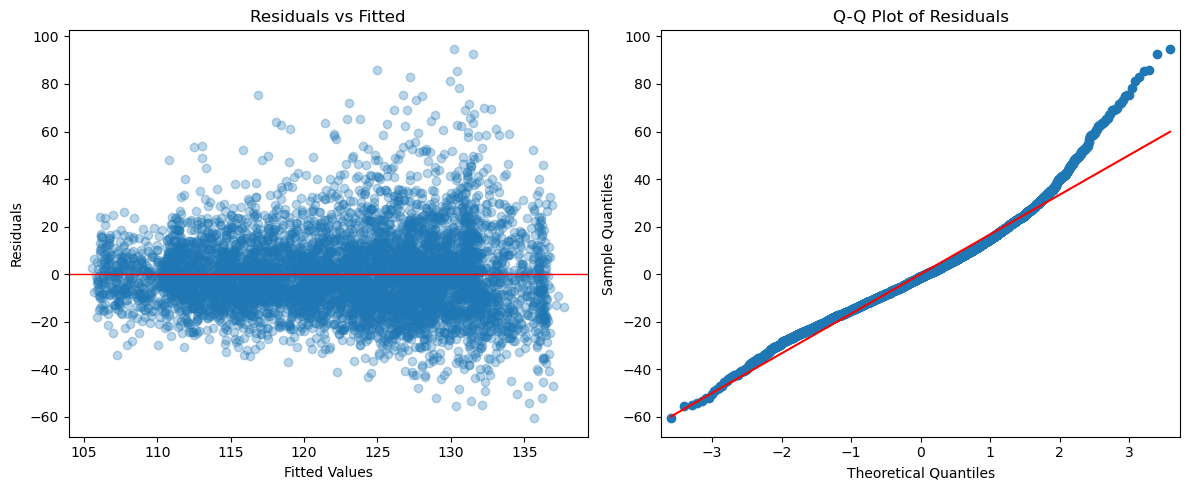

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residual plot
fitted = model.fittedvalues
residuals = model.resid

axes[0].scatter(fitted, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

### Interpretation

#### Rerun with robust standard errors (HC3)

In [7]:
model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     347.8
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.30e-269
Time:                        09:52:55   Log-Likelihood:                -25399.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5994   BIC:                         5.084e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         101.3495      1.544     65.647      

After refitting with heteroscedasticity-robust standard errors to address the heteroscedasticity observed in the residuals vs. fitted plot, the coefficients remained unchanged and sleep_hours remains non-significant (p=0.499). Thus, findings are robust even withstanding the violation of homoscedasticity.

## 4. Logistic regression (Y = hypertension_diagnosis)

### Recode hypertension to 0/1

In [8]:
df = pd.read_csv('../Data/nhanes_clean.csv')

#Un-code sex
df['sex'] = df['sex'].map({1.0: 0, 2.0: 1})

# 1=yes, 2=no → 1=yes, 0=no
df['hypertension_diagnosis'] = df['hypertension_diagnosis'].map({1.0: 1, 2.0: 0})

X = df[['sleep_hours', 'age', 'sex', 'bmi']]
y = df['systolic_bp']
X = sm.add_constant(X)

X_log = df[['sleep_hours', 'age', 'sex', 'bmi']]
y_log = df['hypertension_diagnosis']
X_log = sm.add_constant(X_log)

print(df['hypertension_diagnosis'].value_counts(dropna=False))
print(df['hypertension_diagnosis'].unique())


hypertension_diagnosis
0    3819
1    2180
Name: count, dtype: int64
[1 0]


### Build the model

In [9]:
logit_model = sm.Logit(y_log, X_log).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.530702
         Iterations 6
                             Logit Regression Results                             
Dep. Variable:     hypertension_diagnosis   No. Observations:                 5999
Model:                              Logit   Df Residuals:                     5994
Method:                               MLE   Df Model:                            4
Date:                    Sun, 07 Jun 2026   Pseudo R-squ.:                  0.1902
Time:                            09:52:55   Log-Likelihood:                -3183.7
converged:                           True   LL-Null:                       -3931.4
Covariance Type:                nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.1989      0.248    -25.013      0.000      -6.685      -

In [10]:
# Get odds ratios and confidence intervals
odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int())
conf.columns = ['OR_lower', 'OR_upper']

results = pd.concat([odds_ratios, conf], axis=1)
results.columns = ['Odds Ratio', 'OR_lower', 'OR_upper']
print(results.round(3))

             Odds Ratio  OR_lower  OR_upper
const             0.002     0.001     0.003
sleep_hours       0.990     0.953     1.028
age               1.064     1.060     1.068
sex               0.827     0.733     0.934
bmi               1.083     1.073     1.092


### Interpret odds ratios

### Is the sleep odds ratio significant?

## 5. Interaction models

### Primary Research Question

#### Sleep and Age

In [11]:
df['sleep_age'] = df['sleep_hours'] * df['age']

X_int1 = df[['sleep_hours', 'age', 'sex', 'bmi', 'sleep_age']]
X_int1 = sm.add_constant(X_int1)

model_int1 = sm.OLS(y, X_int1).fit(cov_type='HC3')
print(model_int1.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     278.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.45e-268
Time:                        09:52:56   Log-Likelihood:                -25399.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5993   BIC:                         5.085e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         101.9626      3.016     33.803      

In [13]:
# Center before interactions so the new product term is not highly correlated with the components
df['sleep_c'] = df['sleep_hours'] - df['sleep_hours'].mean()
df['age_c'] = df['age'] - df['age'].mean()
df['bmi_c'] = df['bmi'] - df['bmi'].mean()

df['sleep_age_c'] = df['sleep_c'] * df['age_c']

X_int1c = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'sleep_age_c']]
X_int1c = sm.add_constant(X_int1c)

model_int1c = sm.OLS(y, X_int1c).fit(cov_type='HC3')
print(model_int1c.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     278.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.45e-268
Time:                        09:55:10   Log-Likelihood:                -25399.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5993   BIC:                         5.085e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         129.9901      0.700    185.608      

#### Sleep and Sex

In [16]:
df['sleep_sex'] = df['sleep_c'] * df['sex']

X_int2 = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'sleep_sex']]
X_int2 = sm.add_constant(X_int2)
model_int2 = sm.OLS(y, X_int2).fit(cov_type='HC3')

print(model_int2.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     278.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.05e-268
Time:                        09:56:02   Log-Likelihood:                -25396.
No. Observations:                5999   AIC:                         5.080e+04
Df Residuals:                    5993   BIC:                         5.084e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        129.9498      0.700    185.589      0.0

#### Sleep and BMI

In [18]:
df['sleep_bmi_c'] = df['sleep_c'] * df['bmi_c']

X_int3 = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'sleep_bmi_c']]
X_int3 = sm.add_constant(X_int3)
model_int3 = sm.OLS(y, X_int3).fit(cov_type='HC3')

print(model_int3.summary())


                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     278.1
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.69e-268
Time:                        09:56:17   Log-Likelihood:                -25399.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5993   BIC:                         5.085e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         129.9903      0.700    185.704      

### Visualization of Sleep and Sex Interaction

sex_label
Female    3288
Male      2711
Name: count, dtype: int64


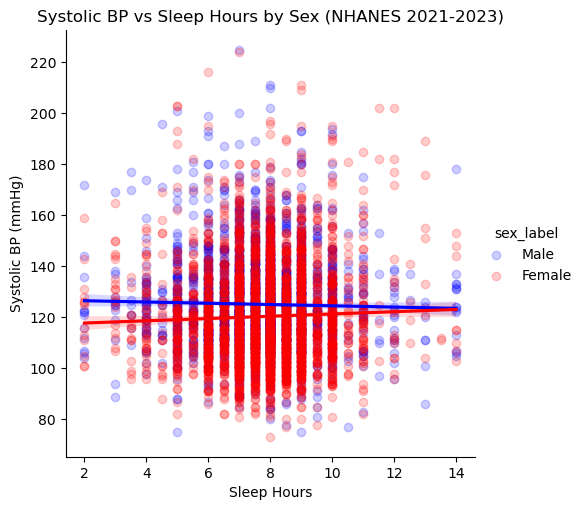

In [28]:
df['sex_label'] = df['sex'].map({1.0: 'Male', 2.0: 'Female'})
print(df['sex_label'].value_counts())


sns.lmplot(data=df, x='sleep_hours', y='systolic_bp',
           hue='sex_label', palette={'Male': 'blue', 'Female': 'red'},
           scatter_kws={'alpha': 0.2})
plt.title('Systolic BP vs Sleep Hours by Sex (NHANES 2021-2023)')
plt.xlabel('Sleep Hours')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

### Secondary Findings

Based on the significance of various variables in part (1), I decided to also check the interaction of bmi, sex, and age. (Insert clinical relevance here)

#### Age and Sex

In [31]:
df['age_sex'] = df['age_c'] * df['sex']

X_int4 = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'age_sex']]
X_int4 = sm.add_constant(X_int4)
model_int4 = sm.OLS(y, X_int4).fit(cov_type='HC3')

print(model_int4.summary())


                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     334.4
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          7.96e-317
Time:                        10:04:55   Log-Likelihood:                -25341.
No. Observations:                5999   AIC:                         5.069e+04
Df Residuals:                    5993   BIC:                         5.073e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        130.0078      0.691    188.136      0.0

#### Age and BMI

In [32]:
df['age_bmi_c'] = df['age_c'] * df['bmi_c']

X_int5 = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'age_bmi_c']]
X_int5 = sm.add_constant(X_int5)
model_int5 = sm.OLS(y, X_int5).fit(cov_type='HC3')

print(model_int5.summary())


                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     286.0
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          3.39e-275
Time:                        10:04:57   Log-Likelihood:                -25394.
No. Observations:                5999   AIC:                         5.080e+04
Df Residuals:                    5993   BIC:                         5.084e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        130.0445      0.699    186.064      0.0

#### BMI and Sex

In [33]:
df['bmi_sex'] = df['bmi_c'] * df['sex']

X_int6 = df[['sleep_c', 'age_c', 'sex', 'bmi_c', 'bmi_sex']]
X_int6 = sm.add_constant(X_int6)
model_int6 = sm.OLS(y, X_int6).fit(cov_type='HC3')
print(model_int6.summary())

                            OLS Regression Results                            
Dep. Variable:            systolic_bp   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     279.0
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          5.21e-269
Time:                        10:07:40   Log-Likelihood:                -25398.
No. Observations:                5999   AIC:                         5.081e+04
Df Residuals:                    5993   BIC:                         5.085e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        129.9531      0.701    185.362      0.0

### Visualizing the Age and BP Interaction

<Figure size 1000x600 with 0 Axes>

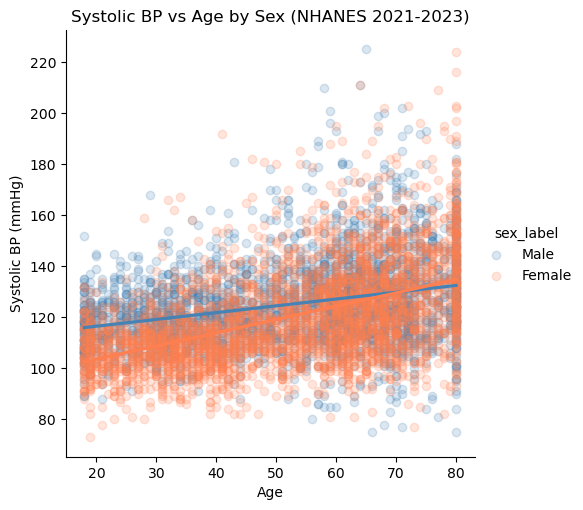

In [34]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x='age', y='systolic_bp',
           hue='sex_label', palette={'Male': 'steelblue', 'Female': 'coral'},
           scatter_kws={'alpha': 0.2})
plt.title('Systolic BP vs Age by Sex (NHANES 2021-2023)')
plt.xlabel('Age')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

## 6. Model Summary

### What is significant?

### Limitations